In [2]:
import numpy as np
import algorithms
import sketches
import helpers
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
MATRICES_DIRECTORY = ""
OUTPUT_DIRECTORY = "Plots"
MATRIX_NAMES = ["smallnorb", "polydecay", "imagenet"]

# Generate Sketch-Powered Low-Rank Factorization Plots

In [7]:
def lrfactors(
    k,
    t,
    num_trials,
    int_sizes,
    max_iterations=5,
    sparse_signs_nnz=1,
    save_png=False,
    output_filename=None,
    output_dir='Plots',
):
    output_paths = []
    for matrix_name in MATRIX_NAMES:
        print(f'{matrix_name} trials')
        print()
        
        with np.load(MATRICES_DIRECTORY+matrix_name+'.npz', allow_pickle=False) as z:
            A = z["A"] #The matrix
            D = z["D"] #Singular values in decreasing order
            A = torch.as_tensor(A, dtype=torch.float32, device=device)

        
    
        metadata = {'matrix':matrix_name, 'k':k, 'num_trials':num_trials}

        curves = []

        for l in int_sizes:

            print(f'Low-Rank Factorization l={l}')
            trial_curves = algorithms.run_nosketch_low_rank_factorization_trials(
                sketches.gaussian,
                sketches.sparse_signs_fixednnz,
                A,
                D,
                k,
                l,
                t,
                num_trials,
                sketch_kwargs_3={"nnz_per":sparse_signs_nnz, "nnz_axis":'c', "format":'t'},
                average=True,
                max_iterations=max_iterations)
            curves.append((f'Low-Rank Factorization l={l}', trial_curves, 'dashed'))
            print()
            
            print(f'Sketch-Powered Low-Rank Factorization l={l}')
            trial_curves = algorithms.run_low_rank_factorization_trials(
                sketches.sparse_signs_fixednnz,
                sketches.gaussian,
                sketches.sparse_signs_fixednnz,
                A,
                D,
                k,
                l,
                t,
                num_trials,
                sketch_kwargs_1={"nnz_per":sparse_signs_nnz, "nnz_axis":'c', "format":'t'},
                sketch_kwargs_3={"nnz_per":sparse_signs_nnz, "nnz_axis":'c', "format":'t'},
                average=True,
                max_iterations=max_iterations*3)
            curves.append((f'Sketch-Powered Low-Rank Factorization l={l}', trial_curves, 'solid'))
            print()

        output_filename=f'LRFactors_{matrix_name}_{k}_{num_trials}trials_{sparse_signs_nnz}nnz.png'

        output_paths.append(helpers.plot_error_curves(curves, metadata, per_iteration_errors=True, save_png=save_png, output_filename=output_filename, output_dir=output_dir))
    return output_paths

smallnorb trials

Low-Rank Factorization l=800
Time taken to form first X = 0.002459052000006068 secs
Time taken to form R = 0.004028684999980214 secs
Time taken to form first Y = 0.00016031699999530247 secs
Average iteration cost = 0.004620696000017688 s
Average factor formation cost = 0.0028942625000164903 s
[(0, 0.0103379515000294, 55530.03125), (1, 0.01591515850001694, 25254.546875), (2, 0.020297881500065767, 22040.828125), (3, 0.02467787250007329, 20774.97265625), (4, 0.029060595500065272, 20300.201171875), (5, 0.03344143150011784, 20008.736328125)]
Time taken to form first X = 0.0019468049999886716 secs
Time taken to form R = 0.003070675999993 secs
Time taken to form first Y = 0.0001523750000274049 secs
Average iteration cost = 0.004387866199988366 s
Average factor formation cost = 0.0026799346666640154 s
[(0, 0.00844125666667613, 44695.55078125), (1, 0.012823922666645634, 22335.04296875), (2, 0.0172081786666259, 20837.712890625), (3, 0.021594519666611706, 20215.828125), (4, 0.02

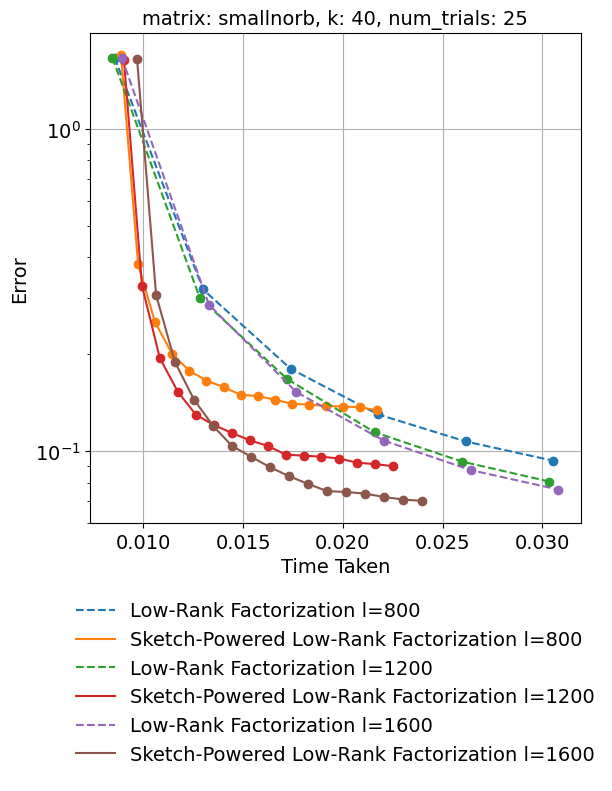

polydecay trials

Low-Rank Factorization l=800
Time taken to form first X = 0.0048710510000091745 secs
Time taken to form R = 0.006125470000029054 secs
Time taken to form first Y = 0.00015447200001972305 secs
Average iteration cost = 0.009734282400006577 s
Average factor formation cost = 0.0031558143333256794 s
[(0, 0.015425727333337136, 2319.30615234375), (1, 0.02643995933337351, 974.7628173828125), (2, 0.0375030133333496, 861.1790161132812), (3, 0.04637123833336432, 816.9459838867188), (4, 0.05523385233337308, 800.8294067382812), (5, 0.06409713933337002, 791.7333984375)]
Time taken to form first X = 0.0038827839999839853 secs
Time taken to form R = 0.004855330999987473 secs
Time taken to form first Y = 0.00016863500002273213 secs
Average iteration cost = 0.00885043040001392 s
Average factor formation cost = 0.00282457783334659 s
[(0, 0.012588144833339735, 2210.313232421875), (1, 0.021417444833341886, 912.833740234375), (2, 0.03028902283336758, 811.0636596679688), (3, 0.03914732483338

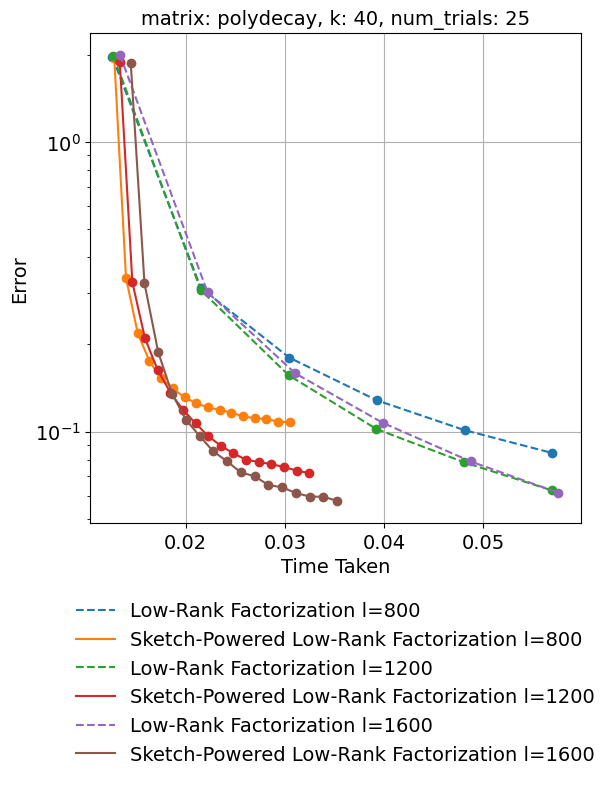

imagenet trials

Low-Rank Factorization l=800
Time taken to form first X = 0.00947113300003366 secs
Time taken to form R = 0.011886484999990898 secs
Time taken to form first Y = 0.00015724200000022392 secs
Average iteration cost = 0.02038398820002385 s
Average factor formation cost = 0.002866252499965564 s
[(0, 0.027606588500001788, 1020.5791625976562), (1, 0.04797851550004376, 460.4791259765625), (2, 0.0683803015001369, 418.6231994628906), (3, 0.08875442450014741, 404.3234558105469), (4, 0.10914413050009368, 396.1732177734375), (5, 0.12952652950012103, 390.55633544921875)]
Time taken to form first X = 0.007698486999970555 secs
Time taken to form R = 0.009690497999940817 secs
Time taken to form first Y = 0.0001633480000009513 secs
Average iteration cost = 0.020378126199943836 s
Average factor formation cost = 0.0027533516666646087 s
[(0, 0.022877891666648036, 1149.251953125), (1, 0.04323641466656151, 463.8333435058594), (2, 0.06362880666652397, 410.24871826171875), (3, 0.08398588366649

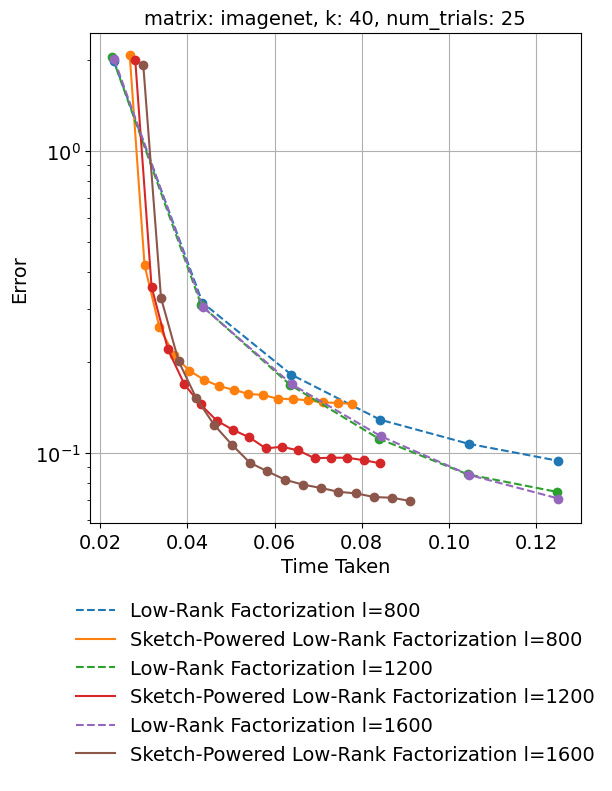

[PosixPath('/content/drive/Othercomputers/My Mac/Desktop/Plots/LRFactors_smallnorb_40_25trials_1nnz.png'),
 PosixPath('/content/drive/Othercomputers/My Mac/Desktop/Plots/LRFactors_polydecay_40_25trials_1nnz.png'),
 PosixPath('/content/drive/Othercomputers/My Mac/Desktop/Plots/LRFactors_imagenet_40_25trials_1nnz.png')]

In [ ]:
lrfactors(
    k=40,
    t=10,
    num_trials=25,
    int_sizes=[800,1200,1600],
    max_iterations=5,
    sparse_signs_nnz=1,
    save_png=True,
    output_dir=OUTPUT_DIRECTORY,
)

# Generate RandSVD Plots

In [10]:
def randsvd(
    k,
    t,
    num_trials,
    int_sizes,
    max_iterations=5,
    sparse_signs_nnz=1,
    save_png=False,
    output_filename=None,
    output_dir='Plots',
):
    output_paths = []
    for matrix_name in MATRIX_NAMES:
        print(f'{matrix_name} trials')
        print()
        
        with np.load(MATRICES_DIRECTORY+matrix_name+'.npz', allow_pickle=False) as z:
            A = z["A"]
            D = z["D"]
            A = torch.as_tensor(A, dtype=torch.float32, device=device)
    
        metadata = {'matrix':matrix_name, 'k':k, 'num_trials':num_trials}

        curves = []

        print('Classical RandSVD')
        classical_trial_curves = algorithms.run_power_iteration_trials(sketches.gaussian, A, D, k, t, num_trials, average=True, max_iterations=max_iterations, svd_param=True)
        curves.append(('Classical RandSVD', classical_trial_curves, 'dashed'))
        print()

        for l in int_sizes:  
            print(f'Sketch-Powered RandSVD l={l}')
            trial_curves = algorithms.run_sketched_power_iteration_trials(sketches.sparse_signs_fixednnz, sketches.gaussian, A, D, k, l, t, num_trials, sketch_kwargs_1={"nnz_per":sparse_signs_nnz, "nnz_axis":'c', "format":'t'}, average=True, max_iterations=max_iterations*3, svd_param=True)
            curves.append((f'Sketch-Powered RandSVD l={l}', trial_curves, 'solid'))
            print()

        output_filename=f'RandSVD_{matrix_name}_{k}_{num_trials}trials_{sparse_signs_nnz}nnz.png'

        output_paths.append(helpers.plot_error_curves(curves, metadata, per_iteration_errors=True, save_png=save_png, output_filename=output_filename, output_dir=output_dir))
    return output_paths

smallnorb trials

Classical RandSVD
Time taken for sketch = 0.0024565839999013406 secs
Average iteration cost = 0.004850549000047976 s
Average factor formation cost = 0.005200067999984033 s
[(0, 0.00877437699997093, 42069.87109375), (1, 0.014344481000042226, 24549.24609375), (2, 0.01989441600013227, 21416.453125), (3, 0.024272525000204343, 20146.115234375), (4, 0.02864859100028146, 19531.962890625), (5, 0.033027122000210817, 19227.748046875)]
Time taken for sketch = 0.0019602889999532636 secs
Average iteration cost = 0.00438177179999002 s
Average factor formation cost = 0.004543358499972783 s
[(0, 0.007250728500025616, 44559.08203125), (1, 0.01163986949984519, 23346.04296875), (2, 0.016012610499842594, 20170.03125), (3, 0.020400614499862968, 19510.546875), (4, 0.02477646549994006, 19258.62890625), (5, 0.029159587499975714, 19103.099609375)]
Time taken for sketch = 0.0019350229999872681 secs
Average iteration cost = 0.004380735799986724 s
Average factor formation cost = 0.00457910600001

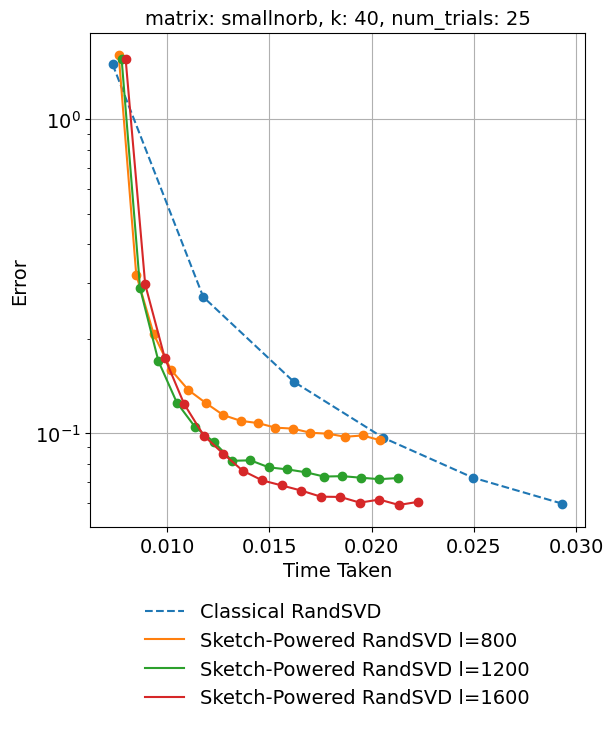

polydecay trials

Classical RandSVD
Time taken for sketch = 0.004776583999955619 secs
Average iteration cost = 0.009238419199982672 s
Average factor formation cost = 0.008306799666684128 s
[(0, 0.01436686366662343, 2068.89599609375), (1, 0.025203520666650547, 914.92626953125), (2, 0.03405351766662079, 838.365966796875), (3, 0.04286318666652278, 810.6067504882812), (4, 0.05171743466655698, 794.52978515625), (5, 0.060558959666536794, 783.8115844726562)]
Time taken for sketch = 0.003864562999979171 secs
Average iteration cost = 0.008839252200004921 s
Average factor formation cost = 0.007639143999995213 s
[(0, 0.012497532999987016, 2105.69775390625), (1, 0.021334459999934552, 882.7089233398438), (2, 0.030147669999905702, 819.2266235351562), (3, 0.039009219000035955, 803.2994995117188), (4, 0.04782928700001321, 796.0899658203125), (5, 0.05669379400001162, 792.3372192382812)]
Time taken for sketch = 0.0038431329999184527 secs
Average iteration cost = 0.008822019999979603 s
Average factor for

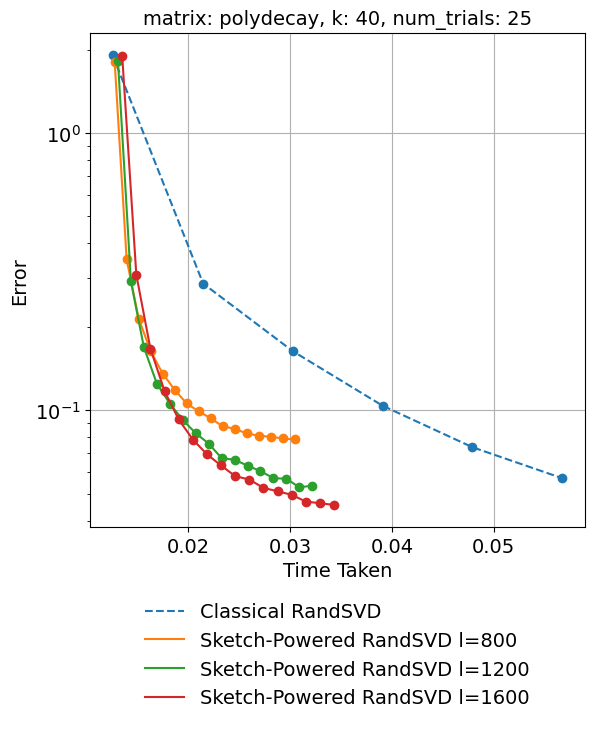

imagenet trials

Classical RandSVD
Time taken for sketch = 0.009831693999785784 secs
Average iteration cost = 0.020368123800062678 s
Average factor formation cost = 0.012980605333306508 s
[(0, 0.026339644333158198, 1032.872802734375), (1, 0.04672186233328072, 441.42779541015625), (2, 0.0670941623334708, 390.8193664550781), (3, 0.08744494433339393, 374.8070068359375), (4, 0.10780744733350882, 370.8207092285156), (5, 0.12818026333347157, 367.1691589355469)]
Time taken for sketch = 0.007733630000075209 secs
Average iteration cost = 0.020371971199983817 s
Average factor formation cost = 0.012431831166660837 s
[(0, 0.022918700166693874, 1003.658203125), (1, 0.04322749316683409, 458.884521484375), (2, 0.06366503716689446, 415.130859375), (3, 0.08403927816679395, 405.1376647949219), (4, 0.10439596116661203, 396.92486572265625), (5, 0.12477855616661297, 388.53765869140625)]
Time taken for sketch = 0.00774122399980115 secs
Average iteration cost = 0.020387471399999413 s
Average factor formation

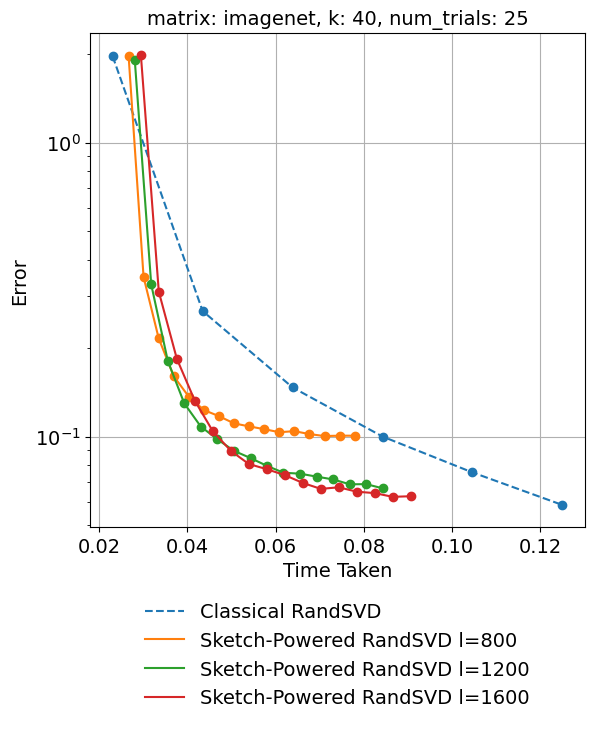

[PosixPath('/content/drive/Othercomputers/My Mac/Desktop/Plots/RandSVD_smallnorb_40_25trials_1nnz.png'),
 PosixPath('/content/drive/Othercomputers/My Mac/Desktop/Plots/RandSVD_polydecay_40_25trials_1nnz.png'),
 PosixPath('/content/drive/Othercomputers/My Mac/Desktop/Plots/RandSVD_imagenet_40_25trials_1nnz.png')]

In [ ]:
randsvd(
    k=40,
    t=10,
    num_trials=25,
    int_sizes=[800,1200,1600],
    max_iterations=5,
    sparse_signs_nnz=1,
    save_png=True,
    output_dir=OUTPUT_DIRECTORY,
)